# Memory Hierarchy

Develop an experiment that exposes the latency and bandwidth effects of the CPU memory hierarchy.

## Objectives

Relate working-set size and access pattern to cache and main-memory behavior.

## Background

Caches exploit temporal and spatial locality; access patterns that exceed or bypass them expose slower memory levels.

## Prediction

A dependent randomized pointer-chasing workload should show increasing access latency as its working set exceeds successive cache capacities. The first transition is expected around the private L1 data-cache capacity, another around the private L2 capacity, and a further transition near the shared L3 capacity. Because CPUs 5 and 15 belong to L3 domains of 8 MiB and 16 MiB respectively, working sets between those capacities may exhibit lower latency on CPU 15. Working sets substantially larger than both L3 caches should approach main-memory latency on both CPUs.

## Environment

In [1]:
import os
import platform
import socket
import sys
from pathlib import Path

repository_root = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").is_file()
    ),
    None,
)
if repository_root is None:
    raise RuntimeError("Run this notebook from within the repository")
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))

print(f"Python: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Hostname: {socket.gethostname()}")
print(f"Working directory: {os.getcwd()}")

Python: 3.14.3 (main, Feb 12 2026, 00:45:04) [Clang 21.1.4 ]
Platform: Linux-6.17.0-1026-nvidia-aarch64-with-glibc2.39
Hostname: spark-0240
Working directory: /home/coert/workspace/dgx-spark-lab/experiments/00-foundations


## Experiment

In [2]:
from pathlib import Path

import pandas as pd


def read_optional(path: Path) -> str | None:
    try:
        return path.read_text().strip()
    except (FileNotFoundError, PermissionError, OSError):
        return None


def cache_entries(cpu_id: int) -> list[dict[str, object]]:
    cache_root = Path(f"/sys/devices/system/cpu/cpu{cpu_id}/cache")
    rows: list[dict[str, object]] = []

    for index_path in sorted(cache_root.glob("index*")):
        rows.append(
            {
                "cpu": cpu_id,
                "index": index_path.name,
                "level": read_optional(index_path / "level"),
                "type": read_optional(index_path / "type"),
                "size": read_optional(index_path / "size"),
                "line_size_bytes": read_optional(index_path / "coherency_line_size"),
                "ways": read_optional(index_path / "ways_of_associativity"),
                "sets": read_optional(index_path / "number_of_sets"),
                "shared_cpu_list": read_optional(index_path / "shared_cpu_list"),
            }
        )

    return rows


REPRESENTATIVE_CPUS = [5, 15]

cache_topology = pd.DataFrame(
    row for cpu_id in REPRESENTATIVE_CPUS for row in cache_entries(cpu_id)
)

for column in [
    "level",
    "line_size_bytes",
    "ways",
    "sets",
]:
    cache_topology[column] = pd.to_numeric(
        cache_topology[column],
        errors="coerce",
    ).astype("Int64")

cache_topology

,cpu,index,level,type,size,line_size_bytes,ways,sets,shared_cpu_list
0,5,index0,1,Data,64K,64,4,256,5
1,5,index1,1,Instruction,64K,64,4,256,5
2,5,index2,2,Unified,2048K,64,8,4096,5
3,5,index3,3,Unified,8192K,64,16,8192,0-9
4,15,index0,1,Data,64K,64,4,256,15
5,15,index1,1,Instruction,64K,64,4,256,15
6,15,index2,2,Unified,2048K,64,8,4096,15
7,15,index3,3,Unified,16384K,64,16,16384,10-19


In [3]:
from pathlib import Path


def cpu_metadata(cpu_id: int) -> dict[str, object]:
    root = Path(f"/sys/devices/system/cpu/cpu{cpu_id}")

    return {
        "cpu": cpu_id,
        "cluster_id": read_optional(root / "topology/cluster_id"),
        "max_frequency_khz": read_optional(root / "cpufreq/cpuinfo_max_freq"),
        "current_frequency_khz": read_optional(root / "cpufreq/scaling_cur_freq"),
    }


representative_cpu_metadata = pd.DataFrame(
    cpu_metadata(cpu_id) for cpu_id in REPRESENTATIVE_CPUS
)

representative_cpu_metadata

,cpu,cluster_id,max_frequency_khz,current_frequency_khz
0,5,56,3900000,3900000
1,15,1144,3900000,3900000


In [4]:
import ctypes
import hashlib
import shutil
import subprocess
import textwrap
from pathlib import Path


C_SOURCE = r"""
#define _GNU_SOURCE

#include <stdint.h>
#include <stddef.h>
#include <stdlib.h>
#include <time.h>

typedef struct __attribute__((aligned(64))) {
    uint32_t next;
    unsigned char padding[60];
} Node;

_Static_assert(sizeof(Node) == 64, "Node must occupy one cache line");

static volatile uint32_t pointer_chase_sink = 0;

static uint64_t xorshift64(uint64_t *state) {
    uint64_t value = *state;
    value ^= value << 13;
    value ^= value >> 7;
    value ^= value << 17;
    *state = value;
    return value;
}

static uint64_t elapsed_ns(
    const struct timespec *start,
    const struct timespec *end
) {
    return (
        (uint64_t)(end->tv_sec - start->tv_sec) * 1000000000ULL
        + (uint64_t)(end->tv_nsec - start->tv_nsec)
    );
}

/*
 * Return nanoseconds per dependent load.
 *
 * Every node occupies one 64-byte cache line. The nodes form one randomized
 * cycle, so each loaded index determines the location of the next load.
 */
double pointer_chase(
    size_t working_set_bytes,
    uint64_t accesses,
    uint64_t seed
) {
    if (working_set_bytes < sizeof(Node) || accesses == 0) {
        return -1.0;
    }

    size_t node_count = working_set_bytes / sizeof(Node);
    size_t allocation_bytes = node_count * sizeof(Node);

    Node *nodes = aligned_alloc(64, allocation_bytes);
    uint32_t *permutation = malloc(node_count * sizeof(uint32_t));

    if (nodes == NULL || permutation == NULL) {
        free(nodes);
        free(permutation);
        return -2.0;
    }

    for (size_t index = 0; index < node_count; ++index) {
        permutation[index] = (uint32_t)index;
    }

    uint64_t random_state = seed == 0 ? 1 : seed;

    for (size_t index = node_count - 1; index > 0; --index) {
        size_t other = xorshift64(&random_state) % (index + 1);

        uint32_t temporary = permutation[index];
        permutation[index] = permutation[other];
        permutation[other] = temporary;
    }

    for (size_t index = 0; index < node_count; ++index) {
        uint32_t current = permutation[index];
        uint32_t next = permutation[(index + 1) % node_count];
        nodes[current].next = next;
    }

    uint32_t current = permutation[0];

    /*
     * Warm up one complete traversal. This faults in the pages and fills
     * whatever cache level can retain the working set.
     */
    for (size_t index = 0; index < node_count; ++index) {
        current = nodes[current].next;
    }

    struct timespec start;
    struct timespec end;

    clock_gettime(CLOCK_MONOTONIC_RAW, &start);

    for (uint64_t index = 0; index < accesses; ++index) {
        current = nodes[current].next;
    }

    clock_gettime(CLOCK_MONOTONIC_RAW, &end);

    pointer_chase_sink = current;

    uint64_t duration_ns = elapsed_ns(&start, &end);

    free(permutation);
    free(nodes);

    return (double)duration_ns / (double)accesses;
}

static volatile uint64_t bandwidth_sink = 0;

double sequential_read_bandwidth(
    size_t working_set_bytes,
    uint64_t passes
) {
    if (working_set_bytes < sizeof(uint64_t) || passes == 0) {
        return -1.0;
    }

    size_t element_count = working_set_bytes / sizeof(uint64_t);
    size_t allocation_bytes = element_count * sizeof(uint64_t);

    uint64_t *values = aligned_alloc(64, allocation_bytes);

    if (values == NULL) {
        return -2.0;
    }

    for (size_t index = 0; index < element_count; ++index) {
        values[index] = (uint64_t)index + 1;
    }

    uint64_t warmup_sum = 0;

    for (size_t index = 0; index < element_count; ++index) {
        warmup_sum += values[index];
    }

    uint64_t sum0 = warmup_sum;
    uint64_t sum1 = 0;
    uint64_t sum2 = 0;
    uint64_t sum3 = 0;
    uint64_t sum4 = 0;
    uint64_t sum5 = 0;
    uint64_t sum6 = 0;
    uint64_t sum7 = 0;

    size_t unrolled_count = element_count - (element_count % 8);

    struct timespec start;
    struct timespec end;

    clock_gettime(CLOCK_MONOTONIC_RAW, &start);

    for (uint64_t pass = 0; pass < passes; ++pass) {
        size_t index = 0;

        for (; index < unrolled_count; index += 8) {
            sum0 += values[index + 0];
            sum1 += values[index + 1];
            sum2 += values[index + 2];
            sum3 += values[index + 3];
            sum4 += values[index + 4];
            sum5 += values[index + 5];
            sum6 += values[index + 6];
            sum7 += values[index + 7];
        }

        for (; index < element_count; ++index) {
            sum0 += values[index];
        }
    }

    clock_gettime(CLOCK_MONOTONIC_RAW, &end);

    bandwidth_sink = (
        sum0 + sum1 + sum2 + sum3
        + sum4 + sum5 + sum6 + sum7
    );

    uint64_t duration_ns = elapsed_ns(&start, &end);
    double bytes_read = (double)allocation_bytes * (double)passes;
    double seconds = (double)duration_ns / 1000000000.0;

    free(values);

    return bytes_read / seconds;
}
"""

In [5]:
# compiler = shutil.which("cc") or shutil.which("clang") or shutil.which("gcc")
compiler = shutil.which("clang") or shutil.which("gcc") or shutil.which("cc")

if compiler is None:
    raise RuntimeError("No C compiler found: expected cc, clang, or gcc")

source_hash = hashlib.sha256(C_SOURCE.encode()).hexdigest()[:12]
build_directory = Path("/tmp/dgx-spark-lab-memory-hierarchy")
build_directory.mkdir(parents=True, exist_ok=True)

source_path = build_directory / f"pointer_chase_{source_hash}.c"
library_path = build_directory / f"pointer_chase_{source_hash}.so"

source_path.write_text(textwrap.dedent(C_SOURCE))

compiler_path = Path(compiler).resolve()
compiler_name = compiler_path.name.lower()

compile_command = [
    compiler,
    "-O3",
    "-std=c11",
    "-shared",
    "-fPIC",
    "-Wall",
    "-Wextra",
]

if "clang" in compiler_name:
    compile_command.extend(
        [
            "-Rpass=loop-vectorize",
            "-Rpass-missed=loop-vectorize",
        ]
    )
elif "gcc" in compiler_name:
    compile_command.extend(
        [
            "-fopt-info-vec-optimized",
            "-fopt-info-vec-missed",
        ]
    )
else:
    print(
        f"Unknown compiler family: {compiler_path}; "
        "continuing without vectorization diagnostics"
    )

compile_command.extend(
    [
        str(source_path),
        "-o",
        str(library_path),
    ]
)

compile_result = subprocess.run(
    compile_command,
    capture_output=True,
    text=True,
    check=False,
)

if compile_result.returncode != 0:
    raise RuntimeError(f"Pointer-chase compilation failed:\n{compile_result.stderr}")

print(compile_result.stderr)

print(f"Compiler: {compiler}")
print(f"Library: {library_path}")

/tmp/dgx-spark-lab-memory-hierarchy/pointer_chase_0c33d9263362.c:99:36: missed: couldn't vectorize loop
/tmp/dgx-spark-lab-memory-hierarchy/pointer_chase_0c33d9263362.c:100:17: missed: not vectorized: unsupported use in stmt.
/tmp/dgx-spark-lab-memory-hierarchy/pointer_chase_0c33d9263362.c:90:34: missed: couldn't vectorize loop
/tmp/dgx-spark-lab-memory-hierarchy/pointer_chase_0c33d9263362.c:91:17: missed: not vectorized: unsupported use in stmt.
/tmp/dgx-spark-lab-memory-hierarchy/pointer_chase_0c33d9263362.c:78:34: missed: couldn't vectorize loop
/tmp/dgx-spark-lab-memory-hierarchy/pointer_chase_0c33d9263362.c:81:29: missed: not vectorized: data ref analysis failed: _26->next = next_71;
/tmp/dgx-spark-lab-memory-hierarchy/pointer_chase_0c33d9263362.c:70:47: missed: couldn't vectorize loop
/tmp/dgx-spark-lab-memory-hierarchy/pointer_chase_0c33d9263362.c:75:28: missed: not vectorized: data ref analysis failed: *_15 = temporary_75;
/tmp/dgx-spark-lab-memory-hierarchy/pointer_chase_0c33d

In [ ]:
source_lines = source_path.read_text().splitlines()

for line_number in [134, 140, 160, 163, 174]:
    start = max(1, line_number - 2)
    end = min(len(source_lines), line_number + 2)

    print(f"\nAround line {line_number}:")
    for current in range(start, end + 1):
        marker = ">" if current == line_number else " "
        print(f"{marker} {current:4d}: {source_lines[current - 1]}")


Around line 134:
   132:     }
   133: 
>  134:     for (size_t index = 0; index < element_count; ++index) {
   135:         values[index] = (uint64_t)index + 1;
   136:     }

Around line 140:
   138:     uint64_t warmup_sum = 0;
   139: 
>  140:     for (size_t index = 0; index < element_count; ++index) {
   141:         warmup_sum += values[index];
   142:     }

Around line 160:
   158:     clock_gettime(CLOCK_MONOTONIC_RAW, &start);
   159: 
>  160:     for (uint64_t pass = 0; pass < passes; ++pass) {
   161:         size_t index = 0;
   162: 

Around line 163:
   161:         size_t index = 0;
   162: 
>  163:         for (; index < unrolled_count; index += 8) {
   164:             sum0 += values[index + 0];
   165:             sum1 += values[index + 1];

Around line 174:
   172:         }
   173: 
>  174:         for (; index < element_count; ++index) {
   175:             sum0 += values[index];
   176:         }


In [7]:
pointer_chase_library = ctypes.CDLL(str(library_path))

pointer_chase_native = pointer_chase_library.pointer_chase
pointer_chase_native.argtypes = [
    ctypes.c_size_t,
    ctypes.c_uint64,
    ctypes.c_uint64,
]
pointer_chase_native.restype = ctypes.c_double


def measure_pointer_chase(
    working_set_bytes: int,
    accesses: int,
    seed: int,
) -> float:
    """Return nanoseconds per dependent cache-line load."""
    result = pointer_chase_native(
        working_set_bytes,
        accesses,
        seed,
    )

    if result < 0:
        raise RuntimeError(f"Native pointer chase failed with result {result}")

    return float(result)

In [8]:
from collections.abc import Iterator
from contextlib import contextmanager


@contextmanager
def pinned_to_cpu(cpu_id: int) -> Iterator[None]:
    """Temporarily restrict the notebook kernel to one logical CPU."""
    original_affinity = os.sched_getaffinity(0)

    if cpu_id not in original_affinity:
        raise ValueError(
            f"CPU {cpu_id} is unavailable; current affinity is "
            f"{sorted(original_affinity)}"
        )

    try:
        os.sched_setaffinity(0, {cpu_id})

        if os.sched_getaffinity(0) != {cpu_id}:
            raise RuntimeError(f"Could not pin process to CPU {cpu_id}")

        yield
    finally:
        os.sched_setaffinity(0, original_affinity)

In [9]:
SANITY_SIZES = {
    "L1-sized": 32 * 1024,
    "L2-sized": 1 * 1024 * 1024,
    "L3-sized": 4 * 1024 * 1024,
    "DRAM-sized": 64 * 1024 * 1024,
}

SANITY_ACCESSES = 5_000_000

sanity_rows = []

with pinned_to_cpu(5):
    for label, size_bytes in SANITY_SIZES.items():
        latency_ns = measure_pointer_chase(
            working_set_bytes=size_bytes,
            accesses=SANITY_ACCESSES,
            seed=20260729,
        )

        sanity_rows.append(
            {
                "label": label,
                "working_set_kib": size_bytes / 1024,
                "latency_ns": latency_ns,
            }
        )

sanity_results = pd.DataFrame(sanity_rows)
sanity_results

,label,working_set_kib,latency_ns
0,L1-sized,32.0,1.287098
1,L2-sized,1024.0,4.573632
2,L3-sized,4096.0,6.269024
3,DRAM-sized,65536.0,63.007709


In [10]:
KIB = 1024
MIB = 1024 * KIB

WORKING_SET_SIZES = [
    4 * KIB,
    8 * KIB,
    16 * KIB,
    24 * KIB,
    32 * KIB,
    48 * KIB,
    64 * KIB,
    96 * KIB,
    128 * KIB,
    192 * KIB,
    256 * KIB,
    384 * KIB,
    512 * KIB,
    768 * KIB,
    1 * MIB,
    1536 * KIB,
    2 * MIB,
    3 * MIB,
    4 * MIB,
    6 * MIB,
    8 * MIB,
    10 * MIB,
    12 * MIB,
    16 * MIB,
    20 * MIB,
    24 * MIB,
    32 * MIB,
    48 * MIB,
    64 * MIB,
    96 * MIB,
    128 * MIB,
]

assert all(size % 64 == 0 for size in WORKING_SET_SIZES)
assert WORKING_SET_SIZES == sorted(set(WORKING_SET_SIZES))

len(WORKING_SET_SIZES)

31

In [11]:
import random
import statistics
import time


REPRESENTATIVE_CPUS = {
    5: {
        "cluster_id": 56,
        "l3_mib": 8,
    },
    15: {
        "cluster_id": 1144,
        "l3_mib": 16,
    },
}

MEASUREMENT_REPETITIONS = 5
ACCESSES_PER_MEASUREMENT = 5_000_000
BASE_SEED = 20260729

measurement_plan = [
    (cpu_id, working_set_bytes, repetition)
    for cpu_id in REPRESENTATIVE_CPUS
    for working_set_bytes in WORKING_SET_SIZES
    for repetition in range(MEASUREMENT_REPETITIONS)
]

# Avoid correlating measurement order with working-set size or CPU.
random.Random(BASE_SEED).shuffle(measurement_plan)

latency_rows = []
experiment_start = time.perf_counter()

for measurement_number, (
    cpu_id,
    working_set_bytes,
    repetition,
) in enumerate(measurement_plan, start=1):
    # seed = BASE_SEED + cpu_id * 1_000_003 + working_set_bytes + repetition
    seed = BASE_SEED + cpu_id * 1_000_003 + working_set_bytes

    with pinned_to_cpu(cpu_id):
        latency_ns = measure_pointer_chase(
            working_set_bytes=working_set_bytes,
            accesses=ACCESSES_PER_MEASUREMENT,
            seed=seed,
        )

    latency_rows.append(
        {
            "cpu": cpu_id,
            "cluster_id": REPRESENTATIVE_CPUS[cpu_id]["cluster_id"],
            "l3_mib": REPRESENTATIVE_CPUS[cpu_id]["l3_mib"],
            "working_set_bytes": working_set_bytes,
            "working_set_kib": working_set_bytes / KIB,
            "working_set_mib": working_set_bytes / MIB,
            "repetition": repetition,
            "latency_ns": latency_ns,
        }
    )

    if measurement_number % 25 == 0:
        elapsed = time.perf_counter() - experiment_start
        print(
            f"{measurement_number}/{len(measurement_plan)} "
            f"measurements completed in {elapsed:.1f} s"
        )

latency_measurements = pd.DataFrame(latency_rows)

print(
    f"Completed {len(latency_measurements)} measurements in "
    f"{time.perf_counter() - experiment_start:.1f} s"
)

latency_measurements.head()

25/310 measurements completed in 1.1 s
50/310 measurements completed in 5.1 s
75/310 measurements completed in 8.9 s
100/310 measurements completed in 10.2 s
125/310 measurements completed in 11.9 s
150/310 measurements completed in 14.9 s
175/310 measurements completed in 15.8 s
200/310 measurements completed in 17.5 s
225/310 measurements completed in 18.7 s
250/310 measurements completed in 23.7 s
275/310 measurements completed in 25.9 s
300/310 measurements completed in 28.2 s
Completed 310 measurements in 29.7 s


,cpu,cluster_id,l3_mib,working_set_bytes,working_set_kib,working_set_mib,repetition,latency_ns
0,15,1144,16,50331648,49152.0,48.000000,0,32.873741
1,5,56,8,4096,4.0,0.003906,0,1.291299
2,5,56,8,16777216,16384.0,16.000000,4,5.511466
3,5,56,8,3145728,3072.0,3.000000,2,6.194054
4,15,1144,16,98304,96.0,0.093750,1,1.381766


In [12]:
latency_summary = (
    latency_measurements.groupby(
        [
            "cpu",
            "cluster_id",
            "l3_mib",
            "working_set_bytes",
            "working_set_kib",
            "working_set_mib",
        ],
        as_index=False,
    )
    .agg(
        minimum_ns=("latency_ns", "min"),
        median_ns=("latency_ns", "median"),
        mean_ns=("latency_ns", "mean"),
        maximum_ns=("latency_ns", "max"),
        standard_deviation_ns=("latency_ns", "std"),
    )
    .sort_values(["cpu", "working_set_bytes"])
    .reset_index(drop=True)
)

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(latency_summary)

,cpu,cluster_id,l3_mib,working_set_bytes,working_set_kib,working_set_mib,minimum_ns,median_ns,mean_ns,maximum_ns,standard_deviation_ns
0,5,56,8,4096,4.0,0.003906,1.283933,1.285997,1.286991,1.291299,0.002809
1,5,56,8,8192,8.0,0.007812,1.286426,1.289206,1.298302,1.336051,0.021169
2,5,56,8,16384,16.0,0.015625,1.283830,1.287526,1.298640,1.343530,0.025241
3,5,56,8,24576,24.0,0.023438,1.283418,1.284435,1.285914,1.291002,0.003193
4,5,56,8,32768,32.0,0.031250,1.284493,1.286755,1.287756,1.292355,0.003400
5,5,56,8,49152,48.0,0.046875,1.284227,1.287050,1.286385,1.288333,0.001784
6,5,56,8,65536,64.0,0.062500,1.286755,1.287898,1.289064,1.293789,0.002774
7,5,56,8,98304,96.0,0.093750,1.397200,1.404560,1.406141,1.417542,0.008264
8,5,56,8,131072,128.0,0.125000,1.439510,1.445235,1.446446,1.455114,0.005724
9,5,56,8,196608,192.0,0.187500,1.542464,1.548416,1.548885,1.553206,0.004313


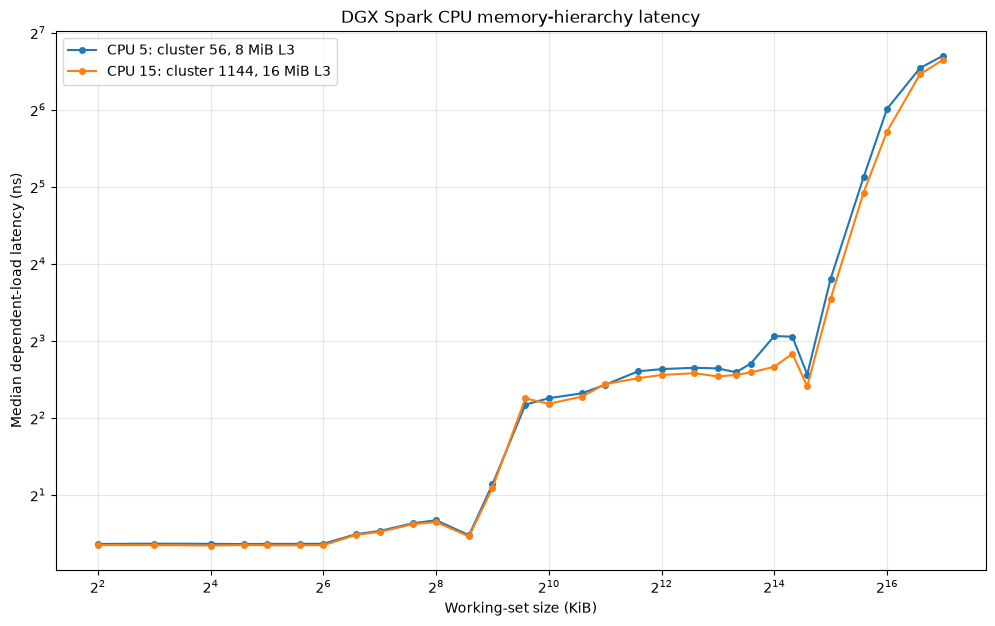

In [13]:
import matplotlib.pyplot as plt


figure, axis = plt.subplots(figsize=(12, 7))

for cpu_id, cpu_results in latency_summary.groupby("cpu"):
    metadata = REPRESENTATIVE_CPUS[int(cpu_id)]

    axis.plot(
        cpu_results["working_set_kib"],
        cpu_results["median_ns"],
        marker="o",
        markersize=4,
        label=(
            f"CPU {cpu_id}: cluster {metadata['cluster_id']}, "
            f"{metadata['l3_mib']} MiB L3"
        ),
    )

axis.set_xscale("log", base=2)
axis.set_yscale("log", base=2)

axis.set_xlabel("Working-set size (KiB)")
axis.set_ylabel("Median dependent-load latency (ns)")
axis.set_title("DGX Spark CPU memory-hierarchy latency")
axis.grid(True, which="both", alpha=0.3)
axis.legend()

plt.show()

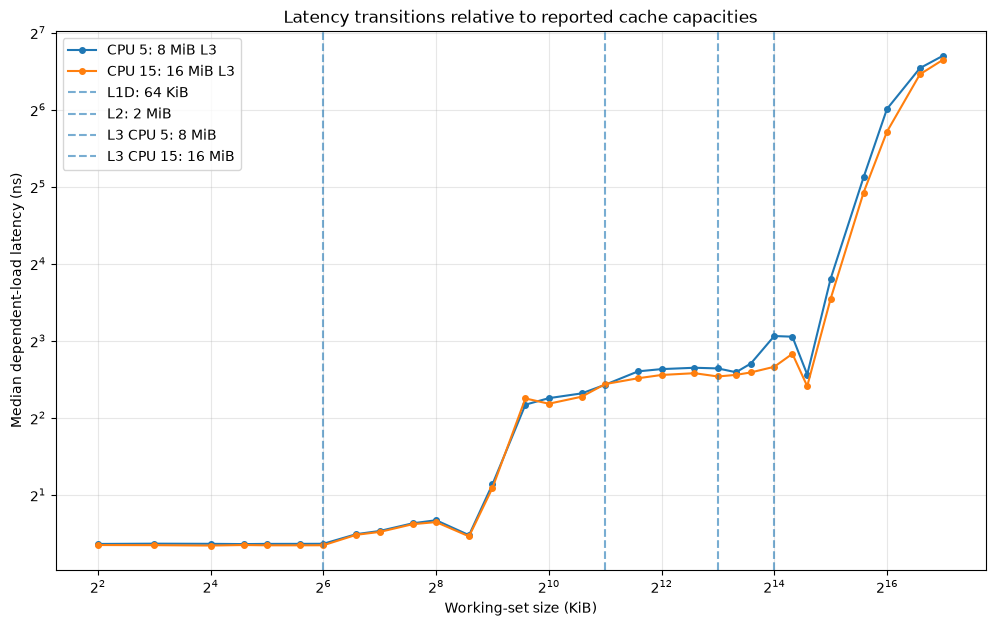

In [14]:
figure, axis = plt.subplots(figsize=(12, 7))

for cpu_id, cpu_results in latency_summary.groupby("cpu"):
    metadata = REPRESENTATIVE_CPUS[int(cpu_id)]

    axis.plot(
        cpu_results["working_set_kib"],
        cpu_results["median_ns"],
        marker="o",
        markersize=4,
        label=(f"CPU {cpu_id}: {metadata['l3_mib']} MiB L3"),
    )

cache_boundaries_kib = {
    "L1D: 64 KiB": 64,
    "L2: 2 MiB": 2 * 1024,
    "L3 CPU 5: 8 MiB": 8 * 1024,
    "L3 CPU 15: 16 MiB": 16 * 1024,
}

for label, boundary_kib in cache_boundaries_kib.items():
    axis.axvline(
        boundary_kib,
        linestyle="--",
        alpha=0.6,
        label=label,
    )

axis.set_xscale("log", base=2)
axis.set_yscale("log", base=2)

axis.set_xlabel("Working-set size (KiB)")
axis.set_ylabel("Median dependent-load latency (ns)")
axis.set_title("Latency transitions relative to reported cache capacities")
axis.grid(True, which="both", alpha=0.3)
axis.legend()

plt.show()

In [15]:
cluster_comparison = latency_summary.pivot(
    index=[
        "working_set_bytes",
        "working_set_kib",
        "working_set_mib",
    ],
    columns="cpu",
    values="median_ns",
).reset_index()

cluster_comparison = cluster_comparison.rename(
    columns={
        5: "cpu_5_latency_ns",
        15: "cpu_15_latency_ns",
    }
)

cluster_comparison["cpu_5_over_cpu_15"] = (
    cluster_comparison["cpu_5_latency_ns"] / cluster_comparison["cpu_15_latency_ns"]
)

cluster_comparison["cpu_15_percent_lower_latency"] = (
    1
    - (cluster_comparison["cpu_15_latency_ns"] / cluster_comparison["cpu_5_latency_ns"])
) * 100

cluster_comparison

cpu,working_set_bytes,working_set_kib,working_set_mib,cpu_5_latency_ns,cpu_15_latency_ns,cpu_5_over_cpu_15,cpu_15_percent_lower_latency
0,4096,4.0,0.003906,1.285997,1.273466,1.009840,0.974435
1,8192,8.0,0.007812,1.289206,1.271926,1.013586,1.340359
2,16384,16.0,0.015625,1.287526,1.267629,1.015697,1.545413
3,24576,24.0,0.023438,1.284435,1.273424,1.008647,0.857280
4,32768,32.0,0.031250,1.286755,1.270234,1.013007,1.283974
5,49152,48.0,0.046875,1.287050,1.270275,1.013205,1.303322
6,65536,64.0,0.062500,1.287898,1.270970,1.013319,1.314390
7,98304,96.0,0.093750,1.404560,1.396438,1.005816,0.578231
8,131072,128.0,0.125000,1.445235,1.432762,1.008706,0.863084
9,196608,192.0,0.187500,1.548416,1.536035,1.008060,0.799578


In [16]:
cluster_comparison.query("8 <= working_set_mib <= 20")

cpu,working_set_bytes,working_set_kib,working_set_mib,cpu_5_latency_ns,cpu_15_latency_ns,cpu_5_over_cpu_15,cpu_15_percent_lower_latency
20,8388608,8192.0,8.0,6.237174,5.800819,1.075223,6.996040
21,10485760,10240.0,10.0,6.026416,5.885536,1.023937,2.337708
22,12582912,12288.0,12.0,6.518368,6.016554,1.083406,7.698467
23,16777216,16384.0,16.0,8.346771,6.329197,1.318773,24.171915
24,20971520,20480.0,20.0,8.296973,7.113517,1.166367,14.263708


In [17]:
FOCUSED_SIZES = [
    6 * MIB,
    7 * MIB,
    8 * MIB,
    9 * MIB,
    10 * MIB,
    12 * MIB,
    14 * MIB,
    16 * MIB,
    18 * MIB,
    20 * MIB,
    24 * MIB,
    28 * MIB,
    32 * MIB,
    40 * MIB,
    48 * MIB,
]

FOCUSED_REPETITIONS = 10
FOCUSED_ACCESSES = 10_000_000

focused_rows = []

for cpu_id in REPRESENTATIVE_CPUS:
    for working_set_bytes in FOCUSED_SIZES:
        fixed_seed = BASE_SEED + cpu_id * 1_000_003 + working_set_bytes

        for repetition in range(FOCUSED_REPETITIONS):
            with pinned_to_cpu(cpu_id):
                latency_ns = measure_pointer_chase(
                    working_set_bytes=working_set_bytes,
                    accesses=FOCUSED_ACCESSES,
                    seed=fixed_seed,
                )

            focused_rows.append(
                {
                    "cpu": cpu_id,
                    "cluster_id": REPRESENTATIVE_CPUS[cpu_id]["cluster_id"],
                    "l3_mib": REPRESENTATIVE_CPUS[cpu_id]["l3_mib"],
                    "working_set_mib": working_set_bytes / MIB,
                    "repetition": repetition,
                    "latency_ns": latency_ns,
                }
            )

focused_measurements = pd.DataFrame(focused_rows)

In [18]:
focused_summary = focused_measurements.groupby(
    ["cpu", "cluster_id", "l3_mib", "working_set_mib"],
    as_index=False,
).agg(
    minimum_ns=("latency_ns", "min"),
    median_ns=("latency_ns", "median"),
    maximum_ns=("latency_ns", "max"),
    standard_deviation_ns=("latency_ns", "std"),
)

focused_summary

,cpu,cluster_id,l3_mib,working_set_mib,minimum_ns,median_ns,maximum_ns,standard_deviation_ns
0,5,56,8,6.0,6.061891,6.133897,6.176277,0.036768
1,5,56,8,7.0,6.125299,6.201478,6.263698,0.038583
2,5,56,8,8.0,5.977507,6.033745,6.070397,0.027048
3,5,56,8,9.0,5.922299,5.979573,6.035206,0.041869
4,5,56,8,10.0,5.913803,5.967543,6.033504,0.041658
5,5,56,8,12.0,5.799146,5.821423,5.880229,0.026197
6,5,56,8,14.0,5.524149,5.567653,6.018603,0.145520
7,5,56,8,16.0,5.350691,5.557862,6.459322,0.382706
8,5,56,8,18.0,5.430915,6.445722,6.840818,0.583260
9,5,56,8,20.0,5.472578,5.516941,7.793069,0.863014


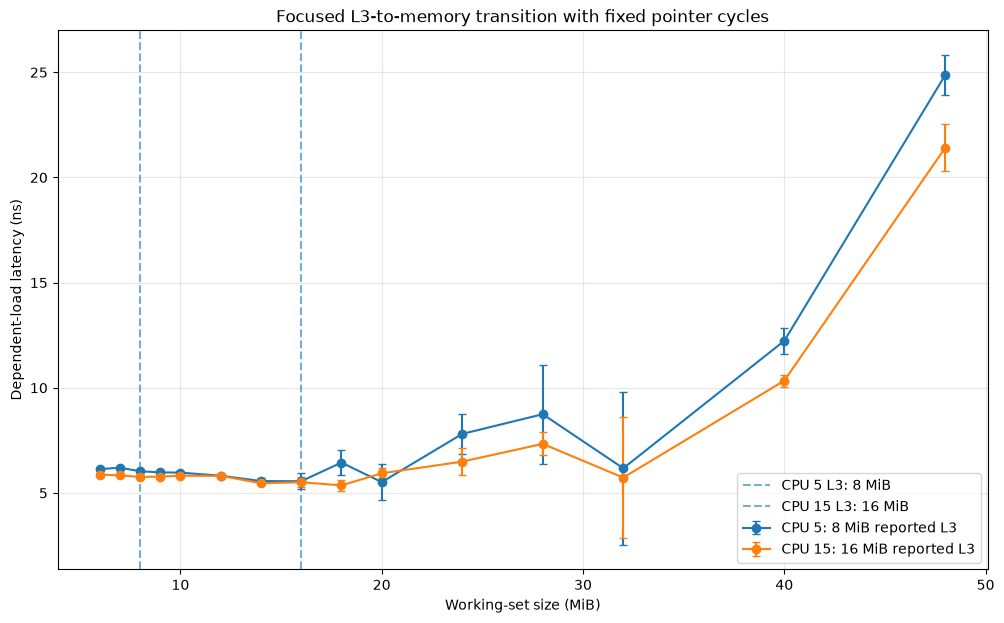

In [19]:
import matplotlib.pyplot as plt


figure, axis = plt.subplots(figsize=(12, 7))

for cpu_id, results in focused_summary.groupby("cpu"):
    metadata = REPRESENTATIVE_CPUS[int(cpu_id)]

    axis.errorbar(
        results["working_set_mib"],
        results["median_ns"],
        yerr=results["standard_deviation_ns"],
        marker="o",
        capsize=3,
        label=(f"CPU {cpu_id}: {metadata['l3_mib']} MiB reported L3"),
    )

axis.axvline(8, linestyle="--", alpha=0.6, label="CPU 5 L3: 8 MiB")
axis.axvline(16, linestyle="--", alpha=0.6, label="CPU 15 L3: 16 MiB")

axis.set_xlabel("Working-set size (MiB)")
axis.set_ylabel("Dependent-load latency (ns)")
axis.set_title("Focused L3-to-memory transition with fixed pointer cycles")
axis.grid(True, alpha=0.3)
axis.legend()

plt.show()

In [20]:
focused_comparison = focused_summary.pivot(
    index="working_set_mib",
    columns="cpu",
    values="median_ns",
).reset_index()

focused_comparison = focused_comparison.rename(
    columns={
        5: "cpu_5_median_ns",
        15: "cpu_15_median_ns",
    }
)

focused_comparison["cpu_15_percent_lower_latency"] = (
    1 - (focused_comparison["cpu_15_median_ns"] / focused_comparison["cpu_5_median_ns"])
) * 100

focused_comparison

cpu,working_set_mib,cpu_5_median_ns,cpu_15_median_ns,cpu_15_percent_lower_latency
0,6.0,6.133897,5.870074,4.301057
1,7.0,6.201478,5.839566,5.835899
2,8.0,6.033745,5.759559,4.544203
3,9.0,5.979573,5.781654,3.309909
4,10.0,5.967543,5.821346,2.449879
5,12.0,5.821423,5.814778,0.114144
6,14.0,5.567653,5.463730,1.866553
7,16.0,5.557862,5.509971,0.861684
8,18.0,6.445722,5.362820,16.800316
9,20.0,5.516941,5.934292,-7.564903


In [21]:
regional_comparison = (
    focused_comparison.assign(
        region=pd.cut(
            focused_comparison["working_set_mib"],
            bins=[0, 8, 16, 32, float("inf")],
            labels=[
                "≤8 MiB",
                "8–16 MiB",
                "16–32 MiB",
                ">32 MiB",
            ],
            include_lowest=True,
        )
    )
    .groupby(
        "region",
        observed=True,
    )
    .agg(
        cpu_5_mean_ns=("cpu_5_median_ns", "mean"),
        cpu_15_mean_ns=("cpu_15_median_ns", "mean"),
        cpu_15_mean_percent_lower_latency=(
            "cpu_15_percent_lower_latency",
            "mean",
        ),
    )
)

regional_comparison

,cpu_5_mean_ns,cpu_15_mean_ns,cpu_15_mean_percent_lower_latency
region,,,
≤8 MiB,6.123040,5.823066,4.893720
8–16 MiB,5.778811,5.678296,1.720434
16–32 MiB,6.937594,6.170727,9.878446
>32 MiB,18.554894,15.879820,14.691220


In [22]:
sequential_read_native = pointer_chase_library.sequential_read_bandwidth

sequential_read_native.argtypes = [
    ctypes.c_size_t,
    ctypes.c_uint64,
]
sequential_read_native.restype = ctypes.c_double


def measure_sequential_bandwidth(
    working_set_bytes: int,
    passes: int,
) -> float:
    bytes_per_second = sequential_read_native(
        working_set_bytes,
        passes,
    )

    if bytes_per_second < 0:
        raise RuntimeError(
            "Native sequential bandwidth benchmark failed "
            f"with result {bytes_per_second}"
        )

    return float(bytes_per_second)

In [23]:
import math
import statistics

BANDWIDTH_SANITY_SIZES = {
    "L1-sized": 32 * KIB,
    "L2-sized": 1 * MIB,
    "L3-sized": 4 * MIB,
    "DRAM-sized": 64 * MIB,
    "Large-DRAM": 256 * MIB,
}

TARGET_BYTES_PER_MEASUREMENT = 4 * 1024**3
BANDWIDTH_REPETITIONS = 5


def passes_for_target_bytes(
    working_set_bytes: int,
    target_bytes: int = TARGET_BYTES_PER_MEASUREMENT,
) -> int:
    return max(1, math.ceil(target_bytes / working_set_bytes))


bandwidth_sanity_rows = []

for cpu_id in REPRESENTATIVE_CPUS:
    for label, working_set_bytes in BANDWIDTH_SANITY_SIZES.items():
        passes = passes_for_target_bytes(working_set_bytes)

        for repetition in range(BANDWIDTH_REPETITIONS):
            with pinned_to_cpu(cpu_id):
                bytes_per_second = measure_sequential_bandwidth(
                    working_set_bytes=working_set_bytes,
                    passes=passes,
                )

            bandwidth_sanity_rows.append(
                {
                    "cpu": cpu_id,
                    "cluster_id": REPRESENTATIVE_CPUS[cpu_id]["cluster_id"],
                    "l3_mib": REPRESENTATIVE_CPUS[cpu_id]["l3_mib"],
                    "label": label,
                    "working_set_bytes": working_set_bytes,
                    "working_set_mib": working_set_bytes / MIB,
                    "passes": passes,
                    "bytes_read_gib": (working_set_bytes * passes / 1024**3),
                    "repetition": repetition,
                    "bandwidth_gb_s": bytes_per_second / 1e9,
                    "bandwidth_gib_s": bytes_per_second / 1024**3,
                }
            )

bandwidth_sanity_measurements = pd.DataFrame(bandwidth_sanity_rows)

bandwidth_sanity_measurements.head()

,cpu,cluster_id,l3_mib,label,working_set_bytes,working_set_mib,passes,bytes_read_gib,repetition,bandwidth_gb_s,bandwidth_gib_s
0,5,56,8,L1-sized,32768,0.03125,131072,4.0,0,123.623503,115.133359
1,5,56,8,L1-sized,32768,0.03125,131072,4.0,1,123.323004,114.853497
2,5,56,8,L1-sized,32768,0.03125,131072,4.0,2,123.787230,115.285842
3,5,56,8,L1-sized,32768,0.03125,131072,4.0,3,123.782493,115.281430
4,5,56,8,L1-sized,32768,0.03125,131072,4.0,4,123.866456,115.359627


In [24]:
bandwidth_sanity_summary = (
    bandwidth_sanity_measurements.groupby(
        [
            "cpu",
            "cluster_id",
            "l3_mib",
            "label",
            "working_set_bytes",
            "working_set_mib",
            "passes",
        ],
        as_index=False,
    )
    .agg(
        minimum_gb_s=("bandwidth_gb_s", "min"),
        median_gb_s=("bandwidth_gb_s", "median"),
        mean_gb_s=("bandwidth_gb_s", "mean"),
        maximum_gb_s=("bandwidth_gb_s", "max"),
        standard_deviation_gb_s=("bandwidth_gb_s", "std"),
    )
    .sort_values(["cpu", "working_set_bytes"])
    .reset_index(drop=True)
)

bandwidth_sanity_summary

,cpu,cluster_id,l3_mib,label,working_set_bytes,working_set_mib,passes,minimum_gb_s,median_gb_s,mean_gb_s,maximum_gb_s,standard_deviation_gb_s
0,5,56,8,L1-sized,32768,0.03125,131072,123.323004,123.782493,123.676537,123.866456,0.216418
1,5,56,8,L2-sized,1048576,1.00000,4096,121.476705,121.656070,121.644681,121.739878,0.109021
2,5,56,8,L3-sized,4194304,4.00000,1024,93.121394,98.037019,97.030661,98.269800,2.196275
3,5,56,8,DRAM-sized,67108864,64.00000,64,34.726957,34.901395,34.875392,34.969485,0.090556
4,5,56,8,Large-DRAM,268435456,256.00000,16,32.169287,32.490762,32.428659,32.538814,0.152659
5,15,1144,16,L1-sized,32768,0.03125,131072,124.688590,125.075287,125.032345,125.319890,0.227618
6,15,1144,16,L2-sized,1048576,1.00000,4096,122.908319,123.950705,123.699420,124.012377,0.463150
7,15,1144,16,L3-sized,4194304,4.00000,1024,106.232481,107.532556,107.336112,107.805837,0.644863
8,15,1144,16,DRAM-sized,67108864,64.00000,64,40.357058,40.689221,40.684819,40.890692,0.215634
9,15,1144,16,Large-DRAM,268435456,256.00000,16,35.259025,35.304702,35.319281,35.398172,0.064692


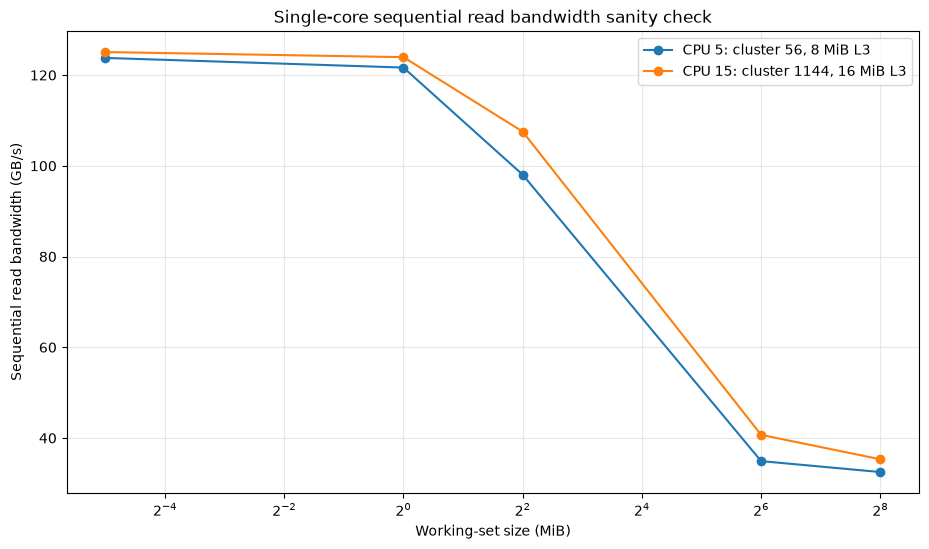

In [25]:
import matplotlib.pyplot as plt


figure, axis = plt.subplots(figsize=(11, 6))

for cpu_id, results in bandwidth_sanity_summary.groupby("cpu"):
    metadata = REPRESENTATIVE_CPUS[int(cpu_id)]

    axis.plot(
        results["working_set_mib"],
        results["median_gb_s"],
        marker="o",
        label=(
            f"CPU {cpu_id}: cluster {metadata['cluster_id']}, "
            f"{metadata['l3_mib']} MiB L3"
        ),
    )

axis.set_xscale("log", base=2)
axis.set_xlabel("Working-set size (MiB)")
axis.set_ylabel("Sequential read bandwidth (GB/s)")
axis.set_title("Single-core sequential read bandwidth sanity check")
axis.grid(True, which="both", alpha=0.3)
axis.legend()

plt.show()

## Observations

The DGX Spark CPU exhibits distinct latency regimes corresponding broadly to private cache, shared cache, and main memory. Dependent-load latency rises from approximately 1.3 ns for small L1-resident working sets to approximately 4 ns in the L2 region, approximately 6 ns in the shared-cache region, and tens to roughly 100 ns for large working sets.

The fixed-layout focused sweep substantially reduced repetition-level variability. The CPU attached to the 16 MiB L3 domain generally exhibited lower dependent-load latency than the CPU attached to the 8 MiB domain, particularly for working sets above approximately 16 MiB. The transition from shared-cache to main-memory behavior was gradual and non-monotonic rather than a sharp boundary at the reported cache capacities. Some working-set sizes, notably 32 MiB, produced unexpectedly low latency on both CPUs, indicating sensitivity to address layout, cache indexing, TLB behavior, or physical-memory mapping.

A single X925 core sustains approximately 31 GB/s while performing a sequential 64-bit summation over cache-resident arrays and approximately 29 GB/s over large DRAM-resident arrays.

## Explanation

Cache capacity is not a hard threshold at which every access suddenly becomes a main-memory access. When a randomized working set exceeds cache capacity, some lines may remain resident while others miss, producing an average latency between pure cache-hit and DRAM latency. Set associativity, replacement policy, address hashing, page translation, and physical-memory placement can also make similarly sized working sets behave differently. The larger L3 domain nevertheless provides a repeatable latency advantage over a broad range of larger working sets.

## Connection to LLMs

Memory hierarchy behavior influences embedding lookup, preprocessing, CPU kernels, and movement of model data.

## Further Exploration

TODO: Vary stride, working-set size, and thread placement independently.